In [1]:
import os
import ot
import gc
import k3d
import torch
import trimesh
import warnings
from tqdm import *
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
from tqdm import tqdm
import seaborn as sns
from pathlib import Path
import scipy.sparse as sp
import matplotlib.cm as cm
from anndata import AnnData
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from numpy.random import RandomState
import matplotlib.font_manager as fm
from matplotlib.gridspec import GridSpec
from sklearn.metrics import jaccard_score
from scipy.stats import fisher_exact, norm
from sklearn.neighbors import NearestNeighbors
from typing import Literal, Optional, Tuple, Union
from matplotlib.colors import ListedColormap, rgb2hex
from sklearn.metrics.pairwise import euclidean_distances
from matplotlib.font_manager import fontManager, FontProperties
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar

import marsilea as ma

In [2]:
import numpy as np
import pandas as pd
from matplotlib.colors import to_rgb, to_hex
import re

def blend_with_white(hex_color, amount=0.0):
    """
    amount=0: 原色
    amount=1: 白色
    """
    rgb = np.array(to_rgb(hex_color))
    white = np.array([1, 1, 1])
    new_rgb = rgb * (1 - amount) + white * amount
    return to_hex(new_rgb)


def build_leiden_palette_from_author(
    adata,
    leiden_key="cell_leiden",
    author_key="author_class",
    class_palette=None,
    min_lighten=0.0,
    max_lighten=0.55,
):
    obs = adata.obs[[leiden_key, author_key]].dropna().copy()

    obs[leiden_key] = obs[leiden_key].astype(str)
    obs[author_key] = obs[author_key].astype(str)

    # Leiden -> author_class composition
    confusion = pd.crosstab(
        obs[leiden_key],
        obs[author_key],
        normalize="index"
    )

    # 每个 Leiden 最相关的 author_class
    best_class = confusion.idxmax(axis=1)
    best_score = confusion.max(axis=1)

    mapping_df = pd.DataFrame({
        "cell_leiden": confusion.index,
        "matched_author_class": best_class.values,
        "matched_fraction": best_score.values,
    })

    leiden_palette = {}

    for author_class, sub_df in mapping_df.groupby("matched_author_class"):
        if class_palette is None or author_class not in class_palette:
            base_color = "#808080"
        else:
            base_color = class_palette[author_class]

        # 同一个 author_class 下，匹配度最高的 Leiden 最接近原色
        sub_df = sub_df.sort_values("matched_fraction", ascending=False)

        n = len(sub_df)

        for rank, (_, row) in enumerate(sub_df.iterrows()):
            leiden = row["cell_leiden"]

            if n == 1:
                lighten = min_lighten
            else:
                lighten = min_lighten + (max_lighten - min_lighten) * rank / (n - 1)

            leiden_palette[leiden] = blend_with_white(base_color, amount=lighten)

    return leiden_palette, mapping_df, confusion

import numpy as np
import pandas as pd
from matplotlib.colors import to_rgb, to_hex
import colorsys


def clamp(x, lo=0.0, hi=1.0):
    return max(lo, min(hi, x))


def tweak_color(
    hex_color,
    lighten=0.0,
    hue_shift=0.0,
    sat_scale=1.0,
):
    """
    在保留原始色系的基础上，调整：
    lighten: 向白色混合，0 原色，1 白色
    hue_shift: 色相偏移，建议小范围，如 -0.06 到 0.06
    sat_scale: 饱和度缩放，>1 更鲜艳，<1 更灰
    """
    r, g, b = to_rgb(hex_color)

    h, l, s = colorsys.rgb_to_hls(r, g, b)

    h = (h + hue_shift) % 1.0
    s = clamp(s * sat_scale)

    r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)

    rgb = np.array([r2, g2, b2])
    white = np.array([1, 1, 1])

    new_rgb = rgb * (1 - lighten) + white * lighten
    return to_hex(new_rgb)


def symmetric_offsets(n, max_shift):
    """
    生成类似：
    0, +1, -1, +2, -2 ...
    这样最重要的 cluster 最接近原色，后面的逐渐偏移。
    """
    if n == 1 or max_shift == 0:
        return [0.0] * n

    offsets = [0.0]
    step = max_shift / max(1, np.ceil((n - 1) / 2))

    k = 1
    while len(offsets) < n:
        offsets.append(k * step)
        if len(offsets) < n:
            offsets.append(-k * step)
        k += 1

    return offsets[:n]


def build_leiden_palette_from_author(
    adata,
    leiden_key="cell_leiden",
    author_key="author_class",
    class_palette=None,
    min_lighten=0.0,
    max_lighten=0.45,
    max_hue_shift=0.07,
    min_sat_scale=0.75,
    max_sat_scale=1.15,
):
    obs = adata.obs[[leiden_key, author_key]].dropna().copy()

    obs[leiden_key] = obs[leiden_key].astype(str)
    obs[author_key] = obs[author_key].astype(str)

    confusion = pd.crosstab(
        obs[leiden_key],
        obs[author_key],
        normalize="index"
    )

    best_class = confusion.idxmax(axis=1)
    best_score = confusion.max(axis=1)

    mapping_df = pd.DataFrame({
        "cell_leiden": confusion.index,
        "matched_author_class": best_class.values,
        "matched_fraction": best_score.values,
    })

    leiden_palette = {}

    for author_class, sub_df in mapping_df.groupby("matched_author_class"):
        if class_palette is None or author_class not in class_palette:
            base_color = "#808080"
        else:
            base_color = class_palette[author_class]

        # 匹配度最高的 Leiden 最接近 author_class 原色
        sub_df = sub_df.sort_values("matched_fraction", ascending=False)

        n = len(sub_df)
        hue_offsets = symmetric_offsets(n, max_hue_shift)

        for rank, (_, row) in enumerate(sub_df.iterrows()):
            leiden = row["cell_leiden"]

            if n == 1:
                lighten = min_lighten
                sat_scale = 1.0
            else:
                t = rank / (n - 1)

                # 亮度逐渐增加
                lighten = min_lighten + (max_lighten - min_lighten) * t

                # 饱和度做轻微变化：前面的更鲜明，后面的略灰一些
                sat_scale = max_sat_scale + (min_sat_scale - max_sat_scale) * t

            leiden_palette[leiden] = tweak_color(
                base_color,
                lighten=lighten,
                hue_shift=hue_offsets[rank],
                sat_scale=sat_scale,
            )

    return leiden_palette, mapping_df, confusion

In [3]:
adata_path = "/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/rapids_analysis/merfish_mouseBrain_concat_embeddings.h5ad"
csv_path = "/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/example/05_merfish_mouseBrain/cluster_to_cluster_annotation_membership.csv"
json_path = "/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/rapids_analysis/author_colormaps/author_colormap.json"


adata = sc.read_h5ad(adata_path)
df = pd.read_csv(csv_path)

def strip_author_id(x):
    return re.sub(r"^\s*\d+\s+", "", str(x)).strip()

class_df = df[df["cluster_annotation_term_set_name"] == "class"].copy()
class_df["cluster_alias"] = class_df["cluster_alias"].astype(str)
class_df["author_class"] = class_df["cluster_annotation_term_name"].map(strip_author_id)

cluster_to_class = (
    class_df
    .drop_duplicates("cluster_alias")
    .set_index("cluster_alias")["author_class"]
    .to_dict()
)

adata.obs["author_class"] = (
    adata.obs["cluster_id_transfer"]
    .astype(str)
    .map(cluster_to_class)
    .astype("category")
)

import json

with open(json_path, "r", encoding="utf-8") as f:
    author_cmap = json.load(f)

print(author_cmap.keys())

class_palette = author_cmap["author_term_set_palettes"]["class"]
cluster_palette = author_cmap["obs_key_palettes"]["cluster_id_transfer"]
subclass_palette = author_cmap["obs_key_palettes"]["subclass_transfer"]

donor_id_colormap = {
    'C57BL6J-1': '#73BBF4', 
    'C57BL6J-2': '#284D76', 
    'C57BL6J-3': '#DF95D5', 
    'C57BL6J-4': '#791E25',
}

dict_keys(['source_membership', 'source_h5ad', 'obs_key_palettes', 'author_term_set_palettes'])


In [4]:
adata = adata[
    adata.obs["major_brain_region"].notna()
    & (adata.obs["major_brain_region"] != "n/a")
].copy()

In [5]:
cell_leiden_palette, leiden_author_map, cell_confusion = build_leiden_palette_from_author(
    adata,
    leiden_key="cell_leiden",
    author_key="subclass_transfer",
    class_palette=subclass_palette,
     min_lighten=0.20,
    max_lighten=0.50,
    max_hue_shift=2.00,
    min_sat_scale=0.50,
    max_sat_scale=100.00
)

In [6]:
import numpy as np
import pandas as pd
from matplotlib.colors import to_rgb, to_hex
import colorsys


def clamp(x, lo=0.0, hi=1.0):
    return max(lo, min(hi, x))


def tweak_color(
    hex_color,
    lighten=0.0,
    hue_shift=0.0,
    sat_scale=1.0,
):
    """
    在保留原始色系的基础上，调整：
    lighten: 向白色混合，0 原色，1 白色
    hue_shift: 色相偏移，建议小范围，如 -0.06 到 0.06
    sat_scale: 饱和度缩放，>1 更鲜艳，<1 更灰
    """
    r, g, b = to_rgb(hex_color)

    h, l, s = colorsys.rgb_to_hls(r, g, b)

    h = (h + hue_shift) % 1.0
    s = clamp(s * sat_scale)

    r2, g2, b2 = colorsys.hls_to_rgb(h, l, s)

    rgb = np.array([r2, g2, b2])
    white = np.array([1, 1, 1])

    new_rgb = rgb * (1 - lighten) + white * lighten
    return to_hex(new_rgb)


def symmetric_offsets(n, max_shift):
    """
    生成类似：
    0, +1, -1, +2, -2 ...
    这样最重要的 cluster 最接近原色，后面的逐渐偏移。
    """
    if n == 1 or max_shift == 0:
        return [0.0] * n

    offsets = [0.0]
    step = max_shift / max(1, np.ceil((n - 1) / 2))

    k = 1
    while len(offsets) < n:
        offsets.append(k * step)
        if len(offsets) < n:
            offsets.append(-k * step)
        k += 1

    return offsets[:n]


def build_leiden_palette_from_author(
    adata,
    leiden_key="cell_leiden",
    author_key="author_class",
    class_palette=None,
    min_lighten=0.00,
    max_lighten=0.45,
    max_hue_shift=0.07,
    min_sat_scale=0.75,
    max_sat_scale=1.15,
):
    obs = adata.obs[[leiden_key, author_key]].dropna().copy()

    obs[leiden_key] = obs[leiden_key].astype(str)
    obs[author_key] = obs[author_key].astype(str)

    confusion = pd.crosstab(
        obs[leiden_key],
        obs[author_key],
        normalize="index"
    )

    best_class = confusion.idxmax(axis=1)
    best_score = confusion.max(axis=1)

    mapping_df = pd.DataFrame({
        "cell_leiden": confusion.index,
        "matched_author_class": best_class.values,
        "matched_fraction": best_score.values,
    })

    leiden_palette = {}

    for author_class, sub_df in mapping_df.groupby("matched_author_class"):
        if class_palette is None or author_class not in class_palette:
            base_color = "#808080"
        else:
            base_color = class_palette[author_class]

        # 匹配度最高的 Leiden 最接近 author_class 原色
        sub_df = sub_df.sort_values("matched_fraction", ascending=False)

        n = len(sub_df)
        hue_offsets = symmetric_offsets(n, max_hue_shift)

        for rank, (_, row) in enumerate(sub_df.iterrows()):
            leiden = row["cell_leiden"]

            if n == 1:
                lighten = min_lighten
                sat_scale = 1.0
            else:
                t = rank / (n - 1)

                # 亮度逐渐增加
                lighten = min_lighten + (max_lighten - min_lighten) * t

                # 饱和度做轻微变化：前面的更鲜明，后面的略灰一些
                sat_scale = max_sat_scale + (min_sat_scale - max_sat_scale) * t

            leiden_palette[leiden] = tweak_color(
                base_color,
                lighten=lighten,
                hue_shift=hue_offsets[rank],
                sat_scale=sat_scale,
            )

    return leiden_palette, mapping_df, confusion

In [7]:
major_brain_region_colormap = {
    'Midbrain': '#FFA6FF',
    'Cerebellum': '#FFFDBC',
    'Isocortex': '#0D9F91',
    'Hippocampus': '#62178d',
    'Cortical_subplate': '#97EC93',
    'Medulla': '#FFA6FF',
    'Olfactory': '#A8ECD3',
    'Fiber_tracts': '#dcb67b',
    'Thalamus': '#FF909F',
    'Hypothalamus': '#F2483B',
    'Pallidum': '#B3C0DF',
    'Pons': '#FFA6FF',
    'Striatum': '#80C0E2',
    'Ventricular_systems': '#AAAAAA',
    'n/a': '#8fec63'
}

niche_leiden_palette, leiden_author_map, niche_confusion = build_leiden_palette_from_author(
    adata,
    leiden_key="niche_leiden",
    author_key="major_brain_region",
    class_palette=major_brain_region_colormap,
    min_lighten=0.20,
    max_lighten=0.50,
    max_hue_shift=2.00,
    min_sat_scale=0.50,
    max_sat_scale=100.00
)

In [8]:
import pandas as pd
import numpy as np

def reorder_confusion_matrix(conf, author_order=None):
    """
    重排混淆矩阵，使相同最佳匹配列的行连续，列顺序与行分组一致，
    产生块对角线的视觉效果。

    Parameters
    ----------
    conf : pd.DataFrame
        混淆矩阵，index = Leiden clusters, columns = author classes，
        值为计数或比例（归一化到行或列均可，内部仅用于找最佳匹配）。
    author_order : list, optional
        自定义列顺序（仅包含部分列名即可），其余列会自动补在后面。

    Returns
    -------
    reordered : pd.DataFrame
        重排后的混淆矩阵。
    row_order : list
        新的行顺序（Leiden 名称列表）。
    col_order : list
        新的列顺序（author 名称列表）。
    """
    # 1. 每行找出最佳匹配列（分数最高）
    best_col = conf.idxmax(axis=1)
    best_score = conf.max(axis=1)

    # 2. 按最佳匹配列分组，组内按匹配分数降序排列
    groups = {}
    for idx, col in best_col.items():
        groups.setdefault(col, []).append(idx)
    row_order = []
    for col in groups:
        # 组内行按分数从高到低排序
        rows = sorted(groups[col], key=lambda r: best_score[r], reverse=True)
        row_order.extend(rows)

    # 3. 确定列顺序
    # 先取出所有被匹配到的列（即有行最佳匹配到它），按它们在 row_order 中首次出现的顺序
    matched_cols = []
    for r in row_order:
        c = best_col[r]
        if c not in matched_cols:
            matched_cols.append(c)

    # 处理用户自定义列顺序
    if author_order is not None:
        # 只保留存在的列，并保证 matched_cols 在前面（按自定义顺序）
        custom_matched = [c for c in author_order if c in matched_cols]
        # 其他 matched_cols 中不在 custom_matched 的追加
        rest_matched = [c for c in matched_cols if c not in custom_matched]
        # 自定义中未匹配到的列（可能是一些没有行的列）放在最后
        other_custom = [c for c in author_order if c in conf.columns and c not in matched_cols]
        col_order = custom_matched + rest_matched + other_custom
    else:
        # 默认：matched_cols 保持原顺序，其余列按总和降序排在后面
        col_order = matched_cols[:]
        remaining = [c for c in conf.columns if c not in col_order]
        # 按列总和降序排列
        col_sums = conf.sum(axis=0)
        remaining_sorted = sorted(remaining, key=lambda c: col_sums[c], reverse=True)
        col_order.extend(remaining_sorted)

    # 4. 重排
    reordered = conf.loc[row_order, col_order]
    return reordered, row_order, col_order

In [9]:
import numpy as np
import pandas as pd


def diagonalize_confusion(
    confusion,
    row_order=None,
    col_order=None,
    row_order_mode="partial",
    col_order_mode="partial",
    row_group_by="best_col",
    within_group_sort=True,
    ascending=False,
):
    """
    将任意 confusion matrix 排成接近对角线/块对角线的形式。

    Parameters
    ----------
    confusion : pd.DataFrame
        行和列都是类别的混淆矩阵。

    row_order : list or None
        手动指定行顺序。
        如果 row_order_mode="full"，则严格使用这个顺序。
        如果 row_order_mode="partial"，则这些行优先，其余行自动补上。

    col_order : list or None
        手动指定列顺序。
        如果 col_order_mode="full"，则严格使用这个顺序。
        如果 col_order_mode="partial"，则这些列优先，其余列自动补上。

    row_group_by : {"best_col", None}
        "best_col": 每一行按最大值所在列分组，适合 Leiden -> author_class 这种多对一关系。
        None: 不按最佳列分组，只使用 row_order 或原始顺序。

    within_group_sort : bool
        在每个最佳列分组内部，是否按该列的值排序。

    ascending : bool
        within_group_sort 的排序方向。默认 False，即匹配值大的排前面。

    Returns
    -------
    reordered : pd.DataFrame
        重排后的 confusion matrix。

    final_row_order : list
        最终行顺序。

    final_col_order : list
        最终列顺序。

    row_to_best_col : pd.Series
        每一行对应的最佳列。
    """

    if not isinstance(confusion, pd.DataFrame):
        confusion = pd.DataFrame(confusion)

    mat = confusion.copy()

    def _clean_requested_order(requested, available):
        if requested is None:
            return []

        available_set = set(available)
        cleaned = []

        for x in requested:
            if x in available_set and x not in cleaned:
                cleaned.append(x)

        return cleaned

    def _complete_order(available, requested, mode):
        requested = _clean_requested_order(requested, available)

        if mode == "full":
            return requested

        if mode == "partial":
            requested_set = set(requested)
            rest = [x for x in available if x not in requested_set]
            return requested + rest

        raise ValueError("mode must be 'full' or 'partial'")

    # ---------- columns ----------
    if col_order is None:
        # 默认列顺序：按列总量从大到小
        auto_col_order = mat.sum(axis=0).sort_values(ascending=False).index.tolist()
        final_col_order = auto_col_order
    else:
        if col_order_mode == "full":
            final_col_order = _complete_order(mat.columns, col_order, mode="full")
        else:
            # 手动指定的列优先，其余列按总量自动补上
            manual_cols = _clean_requested_order(col_order, mat.columns)
            remaining_cols = [c for c in mat.columns if c not in set(manual_cols)]
            remaining_cols = (
                mat[remaining_cols]
                .sum(axis=0)
                .sort_values(ascending=False)
                .index
                .tolist()
            )
            final_col_order = manual_cols + remaining_cols

    mat = mat.loc[:, final_col_order]

    # ---------- rows ----------
    row_to_best_col = mat.idxmax(axis=1)

    if row_order is not None and row_order_mode == "full":
        final_row_order = _complete_order(mat.index, row_order, mode="full")

    elif row_group_by == "best_col":
        manual_rows = _clean_requested_order(row_order, mat.index)
        manual_row_set = set(manual_rows)

        auto_rows = []

        for col in final_col_order:
            rows_in_group = row_to_best_col[row_to_best_col == col].index.tolist()
            rows_in_group = [r for r in rows_in_group if r not in manual_row_set]

            if within_group_sort:
                rows_in_group = (
                    mat.loc[rows_in_group, col]
                    .sort_values(ascending=ascending)
                    .index
                    .tolist()
                )

            auto_rows.extend(rows_in_group)

        # 补上极端情况下没有进入任何 group 的行
        used = set(manual_rows + auto_rows)
        leftovers = [r for r in mat.index if r not in used]

        final_row_order = manual_rows + auto_rows + leftovers

    elif row_group_by is None:
        final_row_order = _complete_order(mat.index, row_order, mode=row_order_mode)

    else:
        raise ValueError("row_group_by must be 'best_col' or None")

    reordered = mat.loc[final_row_order, final_col_order]

    return reordered, final_row_order, final_col_order, row_to_best_col

In [10]:
niche_confusion, final_row_order, final_col_order, row_to_best_col= diagonalize_confusion(
    niche_confusion,
    col_order = ["Olfactory", "Isocortex", "Hippocampus", "Cortical_subplate", "Striatum", "Pallidum", "Thalamus", "Hypothalamus", "Midbrain", "Pons", "Medulla", "Cerebellum", "Fiber_tracts", "Ventricular_systems"],
    col_order_mode = 'full'
)

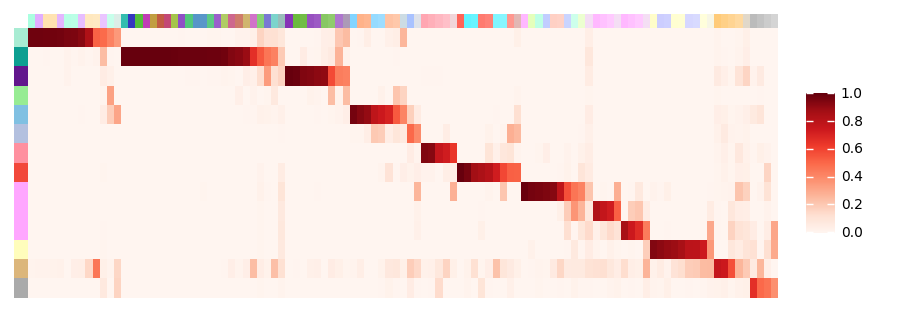

In [11]:
gene_profile = ma.Heatmap(
        niche_confusion.T,
        height=2.7,
        width=7.5,
        cmap="Reds",
    )

gene_profile.group_rows(final_col_order, order=final_col_order, spacing=0)

gene_profile.add_left(
    ma.plotter.Chunk(
        texts=[' ' for i in range(len(final_col_order))], 
        padding=0, 
        fill_colors=[major_brain_region_colormap[i] for i in final_col_order], 
        borderwidth=0,
    ),
    pad=0.001
)

gene_profile.group_cols(final_row_order, order=final_row_order,spacing = 0)
gene_profile.add_top(
    ma.plotter.Chunk(
        texts = [' ' for i in range(len(final_row_order))], 
        padding=0, 
        fill_colors = [niche_leiden_palette[i] for i in final_row_order], 
        borderwidth = 0),
    pad=0.001
)

gene_profile.add_legends("right", stack_size=1, stack_by="column", align_stacks="top")
gene_profile.render()

plt.savefig("/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/confusion_matrix_niche.pdf", bbox_inches="tight",transparent=True,facecolor='none')
plt.show()

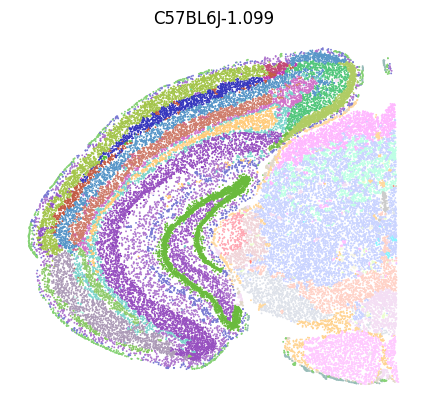

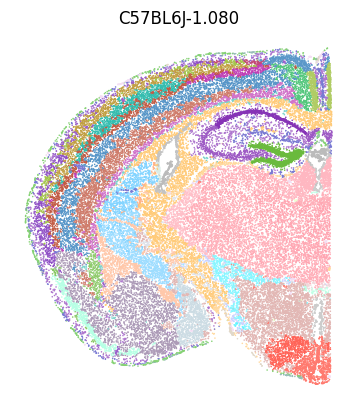

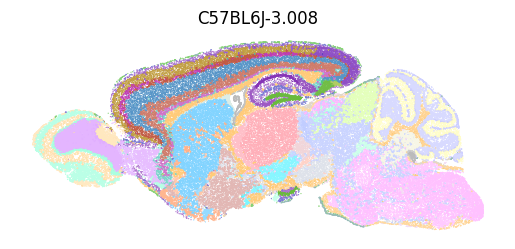

In [12]:

# section_slices = ['C57BL6J-1.099', 'C57BL6J-1.080', 'C57BL6J-3.008']
# for section_slice in section_slices:
#     temp = adata[adata.obs['brain_section_label'] == section_slice].copy()
#     plot = sc.pl.embedding(temp, color = 'major_brain_region', basis = 'X_spatial_coords', 
#                     show=False, s=3, palette = major_brain_region_colormap, frameon = False, title = section_slice, legend_loc = None
#                     # groups = ob_cells
#                           )
#     scalebar = ScaleBar(0.001, "mm", fixed_value=0.5, location = 'lower left', frameon = False,)
#     plot.add_artist(scalebar)
#     plot.set_aspect('equal')
#     plt.savefig(f"/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/spatial_niche/all/author_{section_slice}.png", 
#             bbox_inches="tight",
#             transparent=True,
#             facecolor='none',
#             dpi = 450)
#     plt.close()

section_slices = ['C57BL6J-1.099', 'C57BL6J-1.080', 'C57BL6J-3.008']
sizes = [7, 5, 3]
count = 0
for section_slice in section_slices:
    temp = adata[adata.obs['brain_section_label'] == section_slice].copy()
    plot = sc.pl.embedding(temp, color = 'niche_leiden', basis = 'X_spatial_coords', 
                    show=False, s=sizes[count], palette = niche_leiden_palette, frameon = False, title = section_slice, legend_loc = None
                    # groups = ob_cells
                          )
    # scalebar = ScaleBar(0.001, "mm", fixed_value=0.5, location = 'lower left', frameon = False,)
    # plot.add_artist(scalebar)
    plot.set_aspect('equal')
    plt.show()
    count += 1


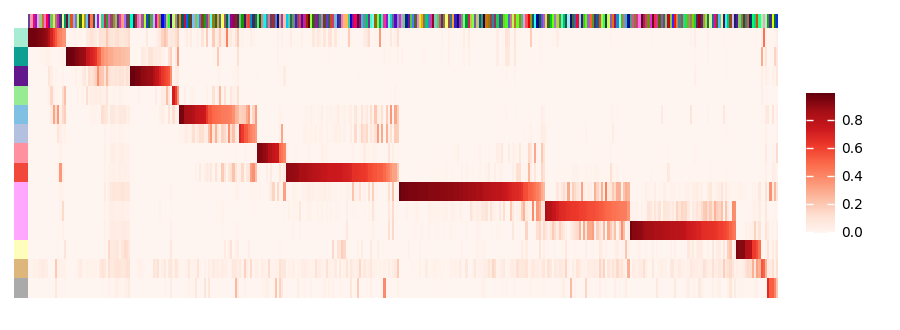

In [13]:
col1 = "subclass_transfer"
col2 = "major_brain_region"

confusion = pd.crosstab(
    adata.obs[col1],
    adata.obs[col2],
    normalize="index",
)

confusion, final_row_order, final_col_order, row_to_best_col= diagonalize_confusion(
    confusion,
    col_order = ["Olfactory", "Isocortex", "Hippocampus", "Cortical_subplate", "Striatum", "Pallidum", "Thalamus", "Hypothalamus", "Midbrain", "Pons", "Medulla", "Cerebellum", "Fiber_tracts", "Ventricular_systems"],
    col_order_mode = 'full'
)
gene_profile = ma.Heatmap(
        confusion.T,
        height=2.7,
        width=7.5,
        cmap="Reds",
    )

gene_profile.group_rows(final_col_order, order=final_col_order, spacing=0)

gene_profile.add_left(
    ma.plotter.Chunk(
        texts=[' ' for i in range(len(final_col_order))], 
        padding=0, 
        fill_colors=[major_brain_region_colormap[i] for i in final_col_order], 
        borderwidth=0,
    ),
    pad=0.001
)

gene_profile.group_cols(final_row_order, order=final_row_order,spacing = 0)
gene_profile.add_top(
    ma.plotter.Chunk(
        texts = [' ' for i in range(len(final_row_order))], 
        padding=0, 
        fill_colors = [subclass_palette[i] for i in final_row_order], 
        borderwidth = 0),
    pad=0.001
)

gene_profile.add_legends("right", stack_size=1, stack_by="column", align_stacks="top")
gene_profile.render()

plt.savefig("/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/confusion_matrix_niche_authorCelltype.pdf", bbox_inches="tight",transparent=True,facecolor='none')
plt.show()

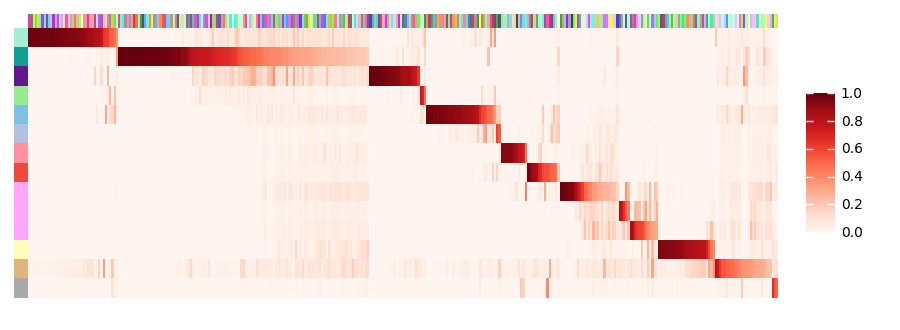

In [14]:
col1 = "cell_leiden"
col2 = "major_brain_region"

confusion = pd.crosstab(
    adata.obs[col1],
    adata.obs[col2],
    normalize="index",
)

confusion, final_row_order, final_col_order, row_to_best_col= diagonalize_confusion(
    confusion,
    col_order = ["Olfactory", "Isocortex", "Hippocampus", "Cortical_subplate", "Striatum", "Pallidum", "Thalamus", "Hypothalamus", "Midbrain", "Pons", "Medulla", "Cerebellum", "Fiber_tracts", "Ventricular_systems"],
    col_order_mode = 'full'
)

gene_profile = ma.Heatmap(
        confusion.T,
        height=2.7,
        width=7.5,
        cmap="Reds",
)

gene_profile.group_rows(final_col_order, order=final_col_order, spacing=0)

gene_profile.add_left(
    ma.plotter.Chunk(
        texts=[' ' for i in range(len(final_col_order))], 
        padding=0, 
        fill_colors=[major_brain_region_colormap[i] for i in final_col_order], 
        borderwidth=0,
    ),
    pad=0.001
)

gene_profile.group_cols(final_row_order, order=final_row_order,spacing = 0)
gene_profile.add_top(
    ma.plotter.Chunk(
        texts = [' ' for i in range(len(final_row_order))], 
        padding=0, 
        fill_colors = [cell_leiden_palette[i] for i in final_row_order], 
        borderwidth = 0),
    pad=0.001
)

gene_profile.add_legends("right", stack_size=1, stack_by="column", align_stacks="top")
gene_profile.render()

plt.savefig("/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/confusion_matrix_niche_leidenCelltype.pdf", bbox_inches="tight",transparent=True,facecolor='none')
plt.show()

In [15]:
col1 = "subclass_transfer"
col2 = "major_brain_region"

confusion = pd.crosstab(
    adata.obs[col1],
    adata.obs[col2],
    normalize="index",
)

confusion, final_row_order, final_col_order, row_to_best_col= diagonalize_confusion(
    confusion,
    col_order = ["Olfactory", "Isocortex", "Hippocampus", "Cortical_subplate", "Striatum", "Pallidum", "Thalamus", "Hypothalamus", "Midbrain", "Pons", "Medulla", "Cerebellum", "Fiber_tracts", "Ventricular_systems"],
    col_order_mode = 'full'
)

In [16]:
cell_confusion, final_row_order, final_col_order, row_to_best_col= diagonalize_confusion(
    cell_confusion,
    col_order = final_row_order,
    col_order_mode = 'full'
)

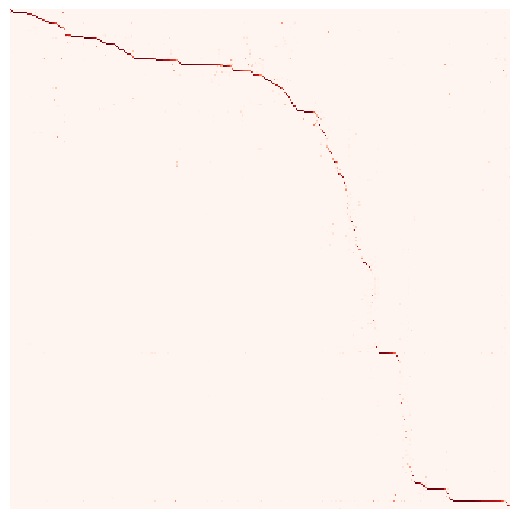

In [17]:
gene_profile = ma.Heatmap(
        cell_confusion.T,
        height=5,
        width=5,
        cmap="Reds",
    )
gene_profile.render()

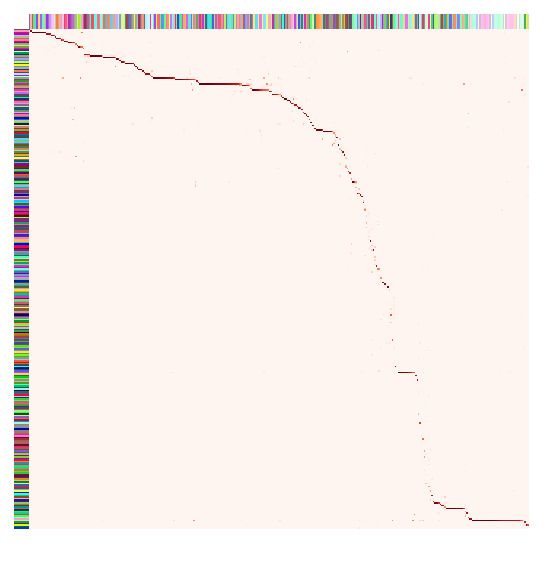

In [18]:
gene_profile = ma.Heatmap(
    cell_confusion.T,
    height=5,
    width=5,
    cmap="Reds",
)

gene_profile.group_rows(
    final_col_order,
    order=final_col_order,
    spacing=0,
)

gene_profile.add_left(
    ma.plotter.Colors(
        final_col_order,
        palette=subclass_palette,
    ),
    size=0.15,
    pad=0.001,
)

gene_profile.group_cols(
    final_row_order,
    order=final_row_order,
    spacing=0,
)

gene_profile.add_top(
    ma.plotter.Colors(
        final_row_order,
        palette=cell_leiden_palette,
    ),
    size=0.15,
    pad=0.001,
)

# gene_profile.add_legends(
#     "right",
#     stack_size=1,
#     stack_by="column",
#     align_stacks="top",
# )

gene_profile.render()

plt.savefig(
    "/home/share/huadjyin/home/zhoutao3/tracks/stereoTrack/out/05_merfish_mouseBrain_mae_v1_3axes_train/figures_out/confusion_matrix_celltype.pdf",
    bbox_inches="tight",
    transparent=True,
    facecolor="none",
)
plt.show()

In [19]:
1

1